<a href="https://colab.research.google.com/github/PCeltide/Algorithms-in-Machine-Learning-and-Their-Application/blob/main/Assignments/Assignment%204/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from numpy.linalg import norm
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix
import scipy.ndimage as ndimage
from scipy.ndimage import convolve

In [2]:
# TensorFlow packages

import tensorflow as tf
from tensorflow import GradientTape
from tensorflow import config
from tensorflow import keras
from keras import layers as layers
from keras import backend as K
from keras.utils import to_categorical
from keras.optimizers import SGD, Adam, AdamW
from keras.models import Model, load_model, clone_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [3]:
from IPython.core.magic import register_cell_magic
# Some 'magic' code to skip cells if you want

@register_cell_magic
def skip(line, cell):
    return

We read in the MNIST data set and format it such that it is compatible with the Keras interface.

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
img_rows, img_cols = 28, 28

X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255
if K.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)
Y_train = keras.utils.to_categorical(y_train, 10)
Y_test = keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


The function `plot_history` below can be used to plot the outcome of Keras' `model.fit` routine.

In [4]:
def plot_history(history):
    x = range(history.params['epochs'])
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    f, axarr = plt.subplots(2, sharex=True)
    axarr[0].set_title('accuracy')
    axarr[0].plot(x, acc, label='train')
    axarr[0].plot(x, val_acc, label='validation')
    axarr[0].legend()

    loss, val_loss = history.history['loss'], history.history['val_loss']
    axarr[1].set_title('loss')
    axarr[1].plot(x, loss, label='train')
    axarr[1].plot(x, val_loss, label='validation')
    axarr[1].legend()

# **Task 4.1**

Implement a class `TwoLayerNN`, which represents a (fully-connected, feed-forward) two-layer neural network, i.e. $L = 2$. The activation functions should be $\phi^{(2)} = \text{ReLU}$ and $\phi^{(3)} = \text{id}$. The weights and biases can be initialized by drawing i.i.d. uniformly distributed random numbers in $(-1, 1)$. The class should contain a method `feedForward` to calculate the point evaluations of $f$ for a whole minibatch at once and a method `backprop` to calculate $\nabla_{W,b}C_B(f)$. To this end, avoid using for-loops over the minibatch and use linear algebra operations (on vectors, matrices or tensors) instead.

In [ ]:
%%skip # We make the final class in the next task
class TwoLayerNN():

    def __init__(self, X, y, h_dim):
        self.X = X
        self.y = y
        self.h_dim = h_dim
        self.m, self.in_dim = X.shape # Datapoints in X are stored in ROWS
        self.out_dim = y.shape[1]

        self.W1 = (np.random.rand(self.in_dim, self.h_dim) - 1/2)*2 # random floats from [-1,1)
        self.b1 = (np.random.rand(1, self.h_dim) - 1/2)*2
        self.W2 = (np.random.rand(self.h_dim, self.out_dim) - 1/2)*2
        self.b2 = (np.random.rand(1, self.out_dim) - 1/2)*2

    def relu(self, z):
        return z * (z > 0)

    def stepwise(self, z):
        return (z > 0).astype(float)

    def feedforward(self, batch):
        # Run a forward propagation
        net_2 = np.dot(batch, self.W1) + self.b1 # Shape: (batch_dim, h_dim)
        o2 = self.relu(net_2)

        net_3 = np.dot(o2, self.W2) + self.b2
        o3 = net_3 # Identity activation

        foward_dict = {'net_2': net_2, 'o2': o2, 'net_3': net_3, 'o3': o3}
        return foward_dict

    def backprop(self, foward_dict, batch, batch_labels):
        # Recall forward variables
        net_2 = foward_dict['net_2']
        o2 = foward_dict['o2']
        net_3 = foward_dict['net_3']
        o3 = foward_dict['o3']

        # Run a backpropagation
        delta_2 = 2 * (o3 - batch_labels) # Shape: (batch_dim, out_dim)
        delta_1 = np.dot(delta_2, self.W2.T) # Shape: (batch_dim, h_dim)

        grad_W2 = np.dot(o2.T, delta_2) # Shape: (h_dim, out_dim)
        grad_b2 = np.sum(delta_2, axis=0, keepdims=True) # Shape: (1, out_dim)

        grad_W1 = np.dot(batch.T, delta_1 * self.stepwise(net_2)) # Shape: (in_dim, h_dim)
        grad_b1 = np.sum(delta_1 * self.stepwise(net_2), axis=0, keepdims=True) # Shape: (1, h_dim)

        grad_dict = {'grad_W2': grad_W2, 'grad_b2': grad_b2, 'grad_W1': grad_W1, 'grad_b1': grad_b1}
        return grad_dict

# **Task 4.2**

Augment the `TwoLayerNN` class by implementing methods to randomly draw a minibatch data set and a method to perform the stochastic minibatch gradient descent algorithm.

In [ ]:
class TwoLayerNN():

    def __init__(self, X, y, h_dim):
        self.X = X
        self.y = y
        self.h_dim = h_dim
        self.m, self.in_dim = X.shape # Datapoints in X are stored in ROWS
        self.out_dim = y.shape[1]

        self.W1 = (np.random.rand(self.in_dim, self.h_dim) - 1/2)*2 # random floats from [-1,1)
        self.b1 = (np.random.rand(1, self.h_dim) - 1/2)*2
        self.W2 = (np.random.rand(self.h_dim, self.out_dim) - 1/2)*2
        self.b2 = (np.random.rand(1, self.out_dim) - 1/2)*2

    def relu(self, z):
        return z * (z > 0)

    def stepwise(self, z):
        return (z > 0).astype(float)

    def feedforward(self, batch):
        # Run a forward propagation
        net_2 = np.dot(batch, self.W1) + self.b1 # Shape: (batch_dim, h_dim)
        o2 = self.relu(net_2)

        net_3 = np.dot(o2, self.W2) + self.b2
        o3 = net_3 # Identity activation

        foward_dict = {'net_2': net_2, 'o2': o2, 'net_3': net_3, 'o3': o3}
        return foward_dict

    def backprop(self, batch, batch_labels, forward_dict):
        # Recall forward variables
        net_2 = forward_dict['net_2']
        o2 = forward_dict['o2']
        net_3 = forward_dict['net_3']
        o3 = forward_dict['o3']

        # Run a backpropagation
        delta_2 = 2 * (o3 - batch_labels) # Shape: (batch_dim, out_dim)
        delta_1 = np.dot(delta_2, self.W2.T) # Shape: (batch_dim, h_dim)

        grad_W2 = np.dot(o2.T, delta_2) # Shape: (h_dim, out_dim)
        grad_b2 = np.sum(delta_2, axis=0, keepdims=True) # Shape: (1, out_dim)

        grad_W1 = np.dot(batch.T, delta_1 * self.stepwise(net_2)) # Shape: (in_dim, h_dim)
        grad_b1 = np.sum(delta_1 * self.stepwise(net_2), axis=0, keepdims=True) # Shape: (1, h_dim)

        grad_dict = {'lse': delta_2/2, 'grad_W2': grad_W2, 'grad_b2': grad_b2, 'grad_W1': grad_W1, 'grad_b1': grad_b1}
        return grad_dict

    def sgd(self, batch_size=20, lr=1e-2, epochs=50000):
        for epoch in range(epochs):
            random_indices = np.random.choice(self.X.shape[0], batch_size, replace=False)
            batch = self.X[random_indices, :]
            batch_labels = self.y[random_indices, :]
            forward_dict = self.feedforward(batch)
            grad_dict = self.backprop(batch, batch_labels, forward_dict)

            self.W1 -= lr * grad_dict['grad_W1']
            self.b1 -= lr * grad_dict['grad_b1']
            self.W2 -= lr * grad_dict['grad_W2']
            self.b2 -= lr * grad_dict['grad_b2']

            if (epoch+1) % 5000 == 0:
                print(f"Batch LSE after {epoch+1} iterations is {(1/batch_size)*np.sum(grad_dict['lse']**2, dtype=np.float64):.6f}")

# **Task 4.3**

Test your implementation by drawing 250 uniformly distributed points $x_i$ in $\mathbb{R}^2$ with $\|x_i\| \le 1$ and label them by $y_i = -1$. Now draw 250 uniformly distributed points $x_i$ in $\mathbb{R}^2$ with $1 < \|x_i\| \le 2$ and label them by $y_i = 1$. Use your two-Layer neural network with $d_2 = 20$ hidden layer neurons, $S = 50000$ iterations and $K = 20$ to classify the data. Try different learning rates $v$. Output the least-squares error every 5000 iterations. After $S$ iterations, make a scatter plot of the data and draw the contour line of your learned classifier. What do you observe? What happens if you increase $S$?

In [ ]:
neg_r, neg_theta = np.sqrt(np.random.rand(250,1)), 2 * np.pi * np.random.rand(250,1)
neg_random_data = np.column_stack((neg_r * np.cos(neg_theta), neg_r * np.sin(neg_theta)))
neg_labels = -np.ones((250,1))

pos_r, pos_theta = np.sqrt(3*np.random.rand(250,1)+1), 2 * np.pi * np.random.rand(250,1)
pos_random_data = np.column_stack((pos_r * np.cos(pos_theta), pos_r * np.sin(pos_theta)))
pos_labels = np.ones((250,1))

mixing_indices = np.random.permutation(500)
X = np.vstack((neg_random_data, pos_random_data))[mixing_indices]
y = np.vstack((neg_labels, pos_labels))[mixing_indices]

In [ ]:
two_deep_NN_lr = TwoLayerNN(X, y, h_dim=20)
two_deep_NN_lr.sgd() # Default learning rate = 1e-2

Batch LSE after 5000 iterations is 0.196527
Batch LSE after 10000 iterations is 0.197934
Batch LSE after 15000 iterations is 0.272059
Batch LSE after 20000 iterations is 0.194983
Batch LSE after 25000 iterations is 0.134866
Batch LSE after 30000 iterations is 0.088040
Batch LSE after 35000 iterations is 0.225135
Batch LSE after 40000 iterations is 0.062388
Batch LSE after 45000 iterations is 0.177418
Batch LSE after 50000 iterations is 0.145441


In [ ]:
two_deep_NN_lr2 = TwoLayerNN(X, y, h_dim=20)
two_deep_NN_lr2.sgd(lr=1e-3) # learning rate = 1e-3

Batch LSE after 5000 iterations is 0.193773
Batch LSE after 10000 iterations is 0.122481
Batch LSE after 15000 iterations is 0.098744
Batch LSE after 20000 iterations is 0.110521
Batch LSE after 25000 iterations is 0.086118
Batch LSE after 30000 iterations is 0.122227
Batch LSE after 35000 iterations is 0.098930
Batch LSE after 40000 iterations is 0.100287
Batch LSE after 45000 iterations is 0.085442
Batch LSE after 50000 iterations is 0.142771


In [ ]:
two_deep_NN_lr3 = TwoLayerNN(X, y, h_dim=20)
two_deep_NN_lr3.sgd(lr=1e-4) # learning rate = 1e-4

Batch LSE after 5000 iterations is 0.318215
Batch LSE after 10000 iterations is 0.281501
Batch LSE after 15000 iterations is 0.243354
Batch LSE after 20000 iterations is 0.185944
Batch LSE after 25000 iterations is 0.193736
Batch LSE after 30000 iterations is 0.350435
Batch LSE after 35000 iterations is 0.125332
Batch LSE after 40000 iterations is 0.131200
Batch LSE after 45000 iterations is 0.188023
Batch LSE after 50000 iterations is 0.233968


In [ ]:
two_deep_NN_lr4 = TwoLayerNN(X, y, h_dim=20)
two_deep_NN_lr4.sgd(lr=5e-4) # learning rate = 5e-4

Batch LSE after 5000 iterations is 0.243166
Batch LSE after 10000 iterations is 0.137378
Batch LSE after 15000 iterations is 0.148625
Batch LSE after 20000 iterations is 0.178299
Batch LSE after 25000 iterations is 0.154733
Batch LSE after 30000 iterations is 0.129302
Batch LSE after 35000 iterations is 0.235428
Batch LSE after 40000 iterations is 0.099972
Batch LSE after 45000 iterations is 0.159927
Batch LSE after 50000 iterations is 0.144981


So, we can deduce that a learning rate of 5e-4 might be a reasonable amount!

In [ ]:
def plot_decision_boundary(model, X, y, title="Decision Boundary of Trained NN", grid_points = 500):

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create a grid of points to evaluate the model on
    x_coords = np.linspace(x_min, x_max, grid_points)
    y_coords = np.linspace(y_min, y_max, grid_points)
    xx, yy = np.meshgrid(x_coords, y_coords)
    grid_input = np.c_[xx.ravel(), yy.ravel()]
    forward_dict_grid = model.feedforward(grid_input)
    Z = forward_dict_grid['o3']
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 8))
    plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.3, cmap=plt.cm.coolwarm)
    plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], label='Class 1', c='firebrick', edgecolors='k')
    plt.scatter(X[y.flatten() == -1, 0], X[y.flatten() == -1, 1], label='Class -1', c='royalblue', edgecolors='k')

    # Set plot labels and appearance
    plt.title(title)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.axis('equal')
    plt.grid(True)
    plt.show()

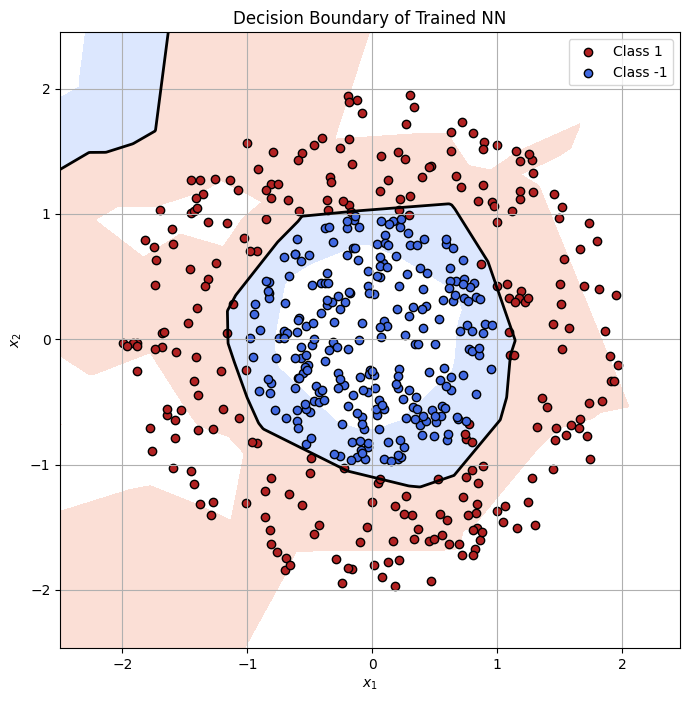

In [ ]:
plot_decision_boundary(two_deep_NN_lr4, X, y)

Let's increase the iterations $S$ now and see if this improves:

In [ ]:
two_deep_NN_lr5 = TwoLayerNN(X, y, h_dim=20)
two_deep_NN_lr5.sgd(lr=5e-4, epochs=100_000) # learning rate = 5e-4

Batch LSE after 5000 iterations is 0.092864
Batch LSE after 10000 iterations is 0.072732
Batch LSE after 15000 iterations is 0.106252
Batch LSE after 20000 iterations is 0.082448
Batch LSE after 25000 iterations is 0.145877
Batch LSE after 30000 iterations is 0.121725
Batch LSE after 35000 iterations is 0.108034
Batch LSE after 40000 iterations is 0.144357
Batch LSE after 45000 iterations is 0.133560
Batch LSE after 50000 iterations is 0.155309
Batch LSE after 55000 iterations is 0.152510
Batch LSE after 60000 iterations is 0.085347
Batch LSE after 65000 iterations is 0.089294
Batch LSE after 70000 iterations is 0.043049
Batch LSE after 75000 iterations is 0.120122
Batch LSE after 80000 iterations is 0.034558
Batch LSE after 85000 iterations is 0.069219
Batch LSE after 90000 iterations is 0.061894
Batch LSE after 95000 iterations is 0.096796
Batch LSE after 100000 iterations is 0.070967


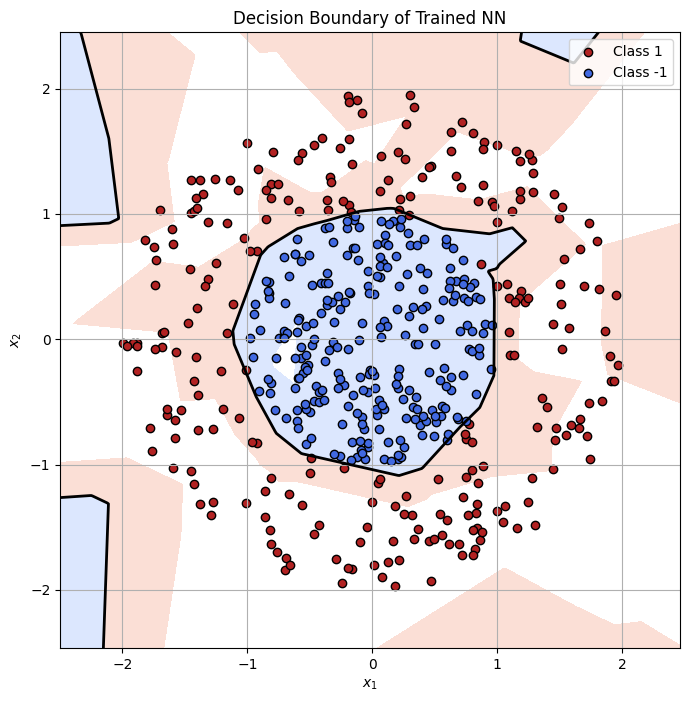

In [ ]:
plot_decision_boundary(two_deep_NN_lr5, X, y)

Notice the model has started to overfit at this point, drawing lines that perfectly match the data, inclusing the gaps.

Lastly, we note that our model could also be descibed as follows, with the help of Keras:

In [ ]:
class PrintLossCallback(keras.callbacks.Callback):
    def __init__(self, frequency):
        super(PrintLossCallback, self).__init__()
        self.frequency = frequency

    def on_epoch_end(self, epoch, logs=None):
        # The 'epoch' is zero-indexed, so we add 1 for printing
        if (epoch + 1) % self.frequency == 0:
            print(f"Epoch {epoch + 1}: loss = {logs['loss']:.6f}, accuracy = {logs['accuracy']:.4f}")

# Construct the model
model = keras.models.Sequential()
model.add(keras.Input(shape=(2,))) # Explicitly define the input shape first
model.add(layers.Dense(20, activation='relu'))
model.add(layers.Dense(1))

# Compile the model
model.compile(loss='mse', optimizer='sgd', metrics=['accuracy'])

In [ ]:
K = 20
S = 50000
total_samples = X.shape[0]  # Should be 500 for your dataset
epochs = int(S / (total_samples / K)) # This calculates to 2000 epochs
print_frequency = 200

history = model.fit(X, y, batch_size=K, epochs=epochs, verbose=0, callbacks=[PrintLossCallback(frequency=print_frequency)])

Epoch 200: loss = 0.241178, accuracy = 0.3640
Epoch 400: loss = 0.230370, accuracy = 0.3580
Epoch 600: loss = 0.222181, accuracy = 0.3540
Epoch 800: loss = 0.216149, accuracy = 0.3660
Epoch 1000: loss = 0.214991, accuracy = 0.3640
Epoch 1200: loss = 0.211001, accuracy = 0.3640
Epoch 1400: loss = 0.210707, accuracy = 0.3720
Epoch 1600: loss = 0.207866, accuracy = 0.3680
Epoch 1800: loss = 0.206059, accuracy = 0.3660
Epoch 2000: loss = 0.200857, accuracy = 0.3740


In [ ]:
def plot_decision_boundary_keras(model, X, y, title="Decision Boundary (Keras)"):

    # Set plot boundaries
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create a grid of points to evaluate the model on
    grid_points = 200
    x_coords = np.linspace(x_min, x_max, grid_points)
    y_coords = np.linspace(y_min, y_max, grid_points)
    xx, yy = np.meshgrid(x_coords, y_coords)
    grid_input = np.c_[xx.ravel(), yy.ravel()]

    # Get predictions from the Keras model
    Z = model.predict(grid_input)
    Z = Z.reshape(xx.shape)

    # Plot the contour and scatter points
    plt.figure(figsize=(8, 8))
    plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.3, cmap=plt.cm.coolwarm)
    plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], label='Class 1', c='firebrick', edgecolors='k')
    plt.scatter(X[y.flatten() == -1, 0], X[y.flatten() == -1, 1], label='Class -1', c='royalblue', edgecolors='k')

    # Set plot labels and appearance
    plt.title(title)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.axis('equal')
    plt.grid(True)
    plt.show()

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


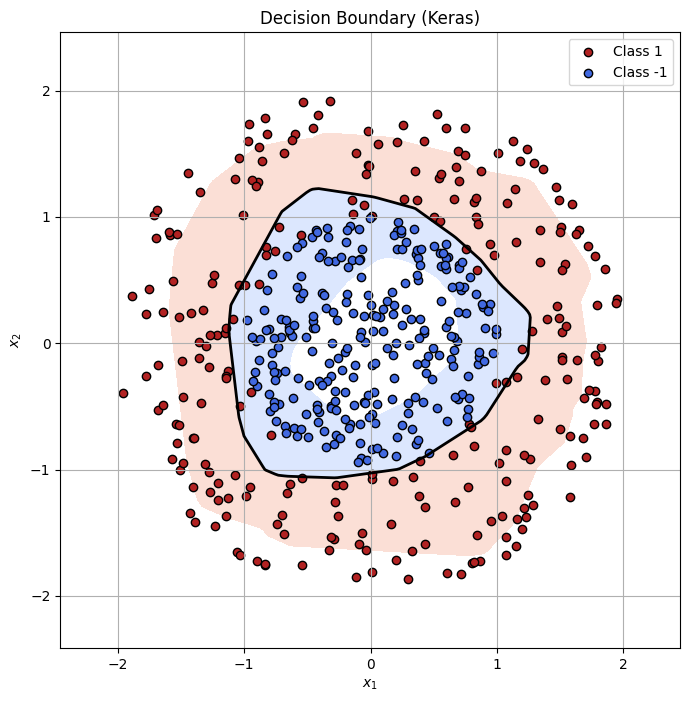

In [ ]:
plot_decision_boundary_keras(model, X, y)

# **Task 4.4**

Use KERAS to build a classifier for the MNIST dataset.

**(a)** Build a model with the following layers:
* Fully-connected layer (Dense) with 128 output nodes + ReLU.
* Fully-connected layer with 128 output nodes + ReLU.
* Fully-connected layer with 10 output nodes + softmax.
Use the SGD optimizer with a batch size of 128 and the categorical crossentropy loss (loss="categorical_crossentropy"), train for 20 episodes. Use the accuracy metric (set in model.compile) and provide the test data as validation data to `model.fit` (set the parameter `validation_data` to (X_test, Y_test)). Plot the fit history (return value of `model.fit`).

In [ ]:
# Flatten and normalize data
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

X_train_norm = X_train_flat/255.0
X_test_norm = X_test_flat/255.0

# Note our labels are already one-hot-encoded for categorical crossentropy
Y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [ ]:
# Construct the model
model = keras.models.Sequential()
model.add(keras.Input(shape=(X_train_norm.shape[1],)))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

print(model.summary())
optimizer = SGD(learning_rate=1e-2, weight_decay=1e-3)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
first_history = model.fit(X_train_norm, Y_train, epochs=20, verbose=True, validation_data=(X_test_norm, Y_test))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.1198 - loss: 2.3005 - val_accuracy: 0.1135 - val_loss: 2.2994
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1117 - loss: 2.2999 - val_accuracy: 0.1135 - val_loss: 2.2992
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1127 - loss: 2.2992 - val_accuracy: 0.1135 - val_loss: 2.2991
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.1133 - loss: 2.2991 - val_accuracy: 0.1135 - val_loss: 2.2990
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.1125 - loss: 2.2989 - val_accuracy: 0.1135 - val_loss: 2.2987
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1107 - loss: 2.2992 - val_accuracy: 0.1135 - val_loss: 2.2985
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1114 - loss: 2.2989 - val_accuracy: 0.1135 - val_loss: 2.2983
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1109 - loss: 2.2989 -

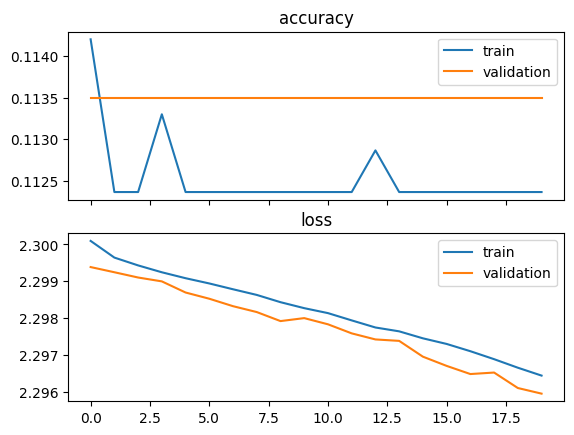

In [ ]:
plot_history(first_history)

(b) Build a new network by adding dropout ($p=0.3$) to the first and second layer of the model from (a). Train it for 250 episodes.


In [ ]:
# Construct the model
dropout_model = keras.models.Sequential()
dropout_model.add(keras.Input(shape=(X_train_norm.shape[1],)))
dropout_model.add(layers.Dense(128, activation='relu'))
dropout_model.add(layers.Dropout(rate=0.3))
dropout_model.add(layers.Dense(128, activation='relu'))
dropout_model.add(layers.Dropout(rate=0.3))
dropout_model.add(layers.Dense(10, activation='softmax'))

print(dropout_model.summary())
optimizer = SGD(learning_rate=1e-2, weight_decay=1e-3)
dropout_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
second_history = dropout_model.fit(X_train_norm, Y_train, epochs=20, verbose=True, validation_data=(X_test_norm, Y_test))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.1176 - loss: 2.3006 - val_accuracy: 0.1135 - val_loss: 2.2995
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.1136 - loss: 2.2997 - val_accuracy: 0.1135 - val_loss: 2.2990
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1150 - loss: 2.2992 - val_accuracy: 0.1135 - val_loss: 2.2989
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.1146 - loss: 2.2993 - val_accuracy: 0.1135 - val_loss: 2.2987
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1128 - loss: 2.2988 - val_accuracy: 0.1135 - val_loss: 2.2986
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1150 - loss: 2.2985 - val_accuracy: 0.1135 - val_loss: 2.2986
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1132 - loss: 2.2986 - val_accuracy: 0.1135 - val_loss: 2.2981
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.1136 - loss: 2.2985

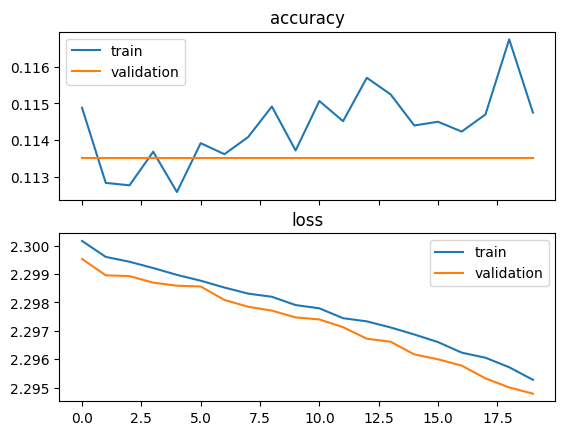

In [ ]:
plot_history(second_history)

(c) Build a third network by using the model from (b) with the optimizer "adam" instead of SGD. Train for 20 episodes.

In [ ]:
# Construct the model
dropout_adam_model = keras.models.Sequential()
dropout_adam_model.add(keras.Input(shape=(X_train_norm.shape[1],)))
dropout_adam_model.add(layers.Dense(128, activation='relu'))
dropout_adam_model.add(layers.Dropout(rate=0.3))
dropout_adam_model.add(layers.Dense(128, activation='relu'))
dropout_adam_model.add(layers.Dropout(rate=0.3))
dropout_adam_model.add(layers.Dense(10, activation='softmax'))

print(dropout_adam_model.summary())
optimizer = Adam(learning_rate=1e-2, weight_decay=1e-3)
dropout_adam_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
third_history = dropout_adam_model.fit(X_train_norm, Y_train, epochs=20, verbose=True, validation_data=(X_test_norm, Y_test))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7138 - loss: 0.8406 - val_accuracy: 0.9224 - val_loss: 0.2465
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8986 - loss: 0.3385 - val_accuracy: 0.9392 - val_loss: 0.1917
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9111 - loss: 0.3011 - val_accuracy: 0.9438 - val_loss: 0.1736
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9133 - loss: 0.2789 - val_accuracy: 0.9469 - val_loss: 0.1740
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9199 - loss: 0.2618 - val_accuracy: 0.9530 - val_loss: 0.1553
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9240 - loss: 0.2539 - val_accuracy: 0.9506 - val_loss: 0.1687
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9235 - loss: 0.2489 - val_accuracy: 0.9495 - val_loss: 0.1714
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9273 - loss: 0.2398

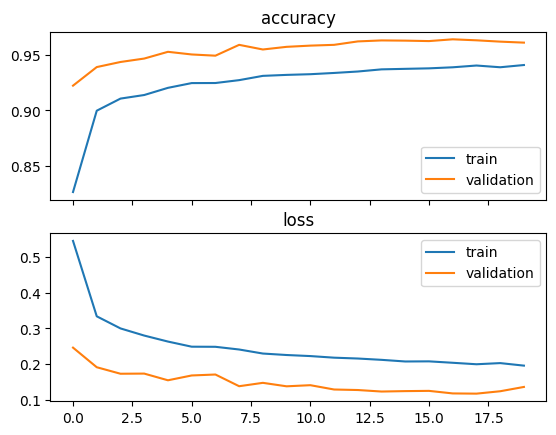

In [ ]:
plot_history(third_history)

# **Task 4.5.**
Build a CNN with KERAS with the following layers:
* 16 parallel conv. layer with kernel size $3 \times 3$ + ReLU.
* 32 parallel conv. layer with kernel size $3 \times 3$ + ReLU.
* A 2D max pooling layer of size $2 \times 2$, non-overlapping + dropout ($p=0.25$).
* Flatten + fully-connected layer with 128 outputs + ReLU + dropout ($p=0.5$).
* Fully-connected layer with output size 10 + softmax.
Train for 15 episodes, the other parameters should be the same as in the previous model. Feel free to change the network/training in order to improve the error.

In [ ]:
# For CNN, we do not flatten data
X_norm_train = X_train / 255.0
X_norm_test = X_test / 255.0

In [ ]:
cnn_model = keras.models.Sequential([keras.Input(shape=X_norm_train.shape[1:]),
                                    keras.layers.Conv2D(filters=32, kernel_size=(5,4), activation='elu'),
                                    keras.layers.Conv2D(filters=32, kernel_size=(4,4), activation='relu'),
                                    keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='elu'),
                                    keras.layers.Dropout(rate=0.15),
                                    keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
                                    keras.layers.MaxPool2D(pool_size=(2, 2)),
                                    keras.layers.Dropout(rate=0.15),
                                    keras.layers.Flatten(),
                                    keras.layers.Dense(units=256, activation='relu'),
                                    keras.layers.Dropout(rate=0.4),
                                    keras.layers.Dense(units=10, activation='softmax')])
print(cnn_model.summary())
#optimizer = Adam(learning_rate=1e-2, weight_decay=1e-4)
cnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 24, 25, 32)     │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 21, 22, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 19, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 19, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 17, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,254,986 (4.79 MB)

 Trainable params: 1,254,986 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
cnn_history = cnn_model.fit(X_norm_train, Y_train, epochs=15, verbose=True, validation_data=(X_norm_test, Y_test), batch_size=128)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.6472 - loss: 0.9891 - val_accuracy: 0.9688 - val_loss: 0.0989
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9633 - loss: 0.1244 - val_accuracy: 0.9810 - val_loss: 0.0592
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9749 - loss: 0.0839 - val_accuracy: 0.9854 - val_loss: 0.0444
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9795 - loss: 0.0702 - val_accuracy: 0.9872 - val_loss: 0.0385
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9827 - loss: 0.0569 - val_accuracy: 0.9868 - val_loss: 0.0430
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9840 - loss: 0.0511 - val_accuracy: 0.9884 - val_loss: 0.0355
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9863 - loss: 0.0463 - val_accuracy: 0.9892 - val_loss: 0.0314
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9879 - loss: 0.0386 - val

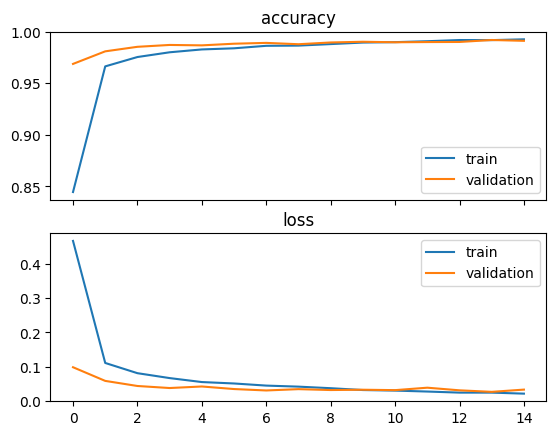

In [ ]:
plot_history(cnn_history)

# **Task 4.6.** (Optional bonus task)
Use a CNN to learn features for pedestrian classification. Proceed as follows:
* Design and train a CNN for pedestrian classification (use the data from section 3.4). You can start with the network from task 4.5.
* Use the output after the flattening (see KERAS' FAQ on how to do this) as a feature vector for a linear SVM, together with the HoG features.
* Try to use PCA in order to improve the accuracy, also tweak the HoG parameters. Make sure not to over-fit (the pedestrian dataset is small in deep learning standards).
* You can also install the AUGMENTOR library for PYTHON in order to enlarge the dataset (common technique in deep learning). We did obtain a 93.5% error rate, but there is definitely room for improvement! You might also want to take a look at the images which got classified wrongly.

## Load Data and Previous Code

In [5]:
import os

print("Cloning repository...")
!git clone https://github.com/PCeltide/Algorithms-in-Machine-Learning-and-Their-Application.git

repo_name = 'Algorithms-in-Machine-Learning-and-Their-Application'
source_folder = f'/content/{repo_name}/Assignments/Assignment 3'
destination_folder = '/content/'

print("\nMoving project files to the main directory...")
!mv /content/Algorithms-in-Machine-Learning-and-Their-Application/Assignments/Assignment\ 3/* {destination_folder}

print("\nVerifying contents of the main /content/ directory:")
!ls -l {destination_folder}

data_file_path = os.path.join(destination_folder, 'data', 'pca_ped_25x50.mat')
if os.path.exists(data_file_path):
    print(f"\nSuccess! Found the data file at: {data_file_path}")
else:
    print("\nError: Could not find the data file after moving.")

Cloning repository...
Cloning into 'Algorithms-in-Machine-Learning-and-Their-Application'...
remote: Enumerating objects: 167, done.
remote: Counting objects: 100% (167/167), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 167 (delta 34), reused 9 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (167/167), 18.05 MiB | 6.36 MiB/s, done.
Resolving deltas: 100% (34/34), done.
Encountered 1 file(s) that should have been pointers, but weren't:
	Assignments/Assignment 3/mllab/pca/hog_ref.mat

Moving project files to the main directory...

Verifying contents of the main /content/ directory:
total 28
drwxr-xr-x 4 root root 4096 Aug 24 10:14  Algorithms-in-Machine-Learning-and-Their-Application
drwxr-xr-x 2 root root 4096 Aug 24 10:14  data
-rw-r--r-- 1 root root 4005 Aug 24 10:14  factor_split.py
drwxr-xr-x 2 root root 4096 Aug 24 10:14  hog
drwxr-xr-x 3 root root 4096 Aug 24 10:14  mllab
drwxr-xr-x 2 root root 4096 Aug 24 10:14 'sample data'
drwxr-xr-x 1 root r

In [4]:
import mllab.pca
mllab.pca.load_pedestrian_images?

In [5]:
def SVM_classifier(data, classification, test_data, test_classification):
    model = LinearSVC(C=0.01, max_iter=5000)
    model.fit(data, classification)
    prediction = model.predict(test_data)
    conf_mat = confusion_matrix(test_classification, prediction)
    acc = accuracy_score(test_classification, prediction)
    misclassified_indices = np.where(prediction != test_classification)[0]

    return conf_mat, acc, prediction, misclassified_indices

In [6]:
class HogFeatures:
    def __init__(self, im_shape, n_bins=9, cell_size=8, blk_size=2, unsigned=True, clip_val=.2):
        self.deg_range = np.pi if unsigned else 2 * np.pi
        self.n_bins = n_bins
        self.bins = np.linspace(0, self.deg_range, n_bins, endpoint=False)
        self.bin_size = self.deg_range / n_bins
        self.cell_size = cell_size
        self.blk_size = blk_size
        self.clip_val = clip_val

        self.im_h, self.im_w = im_shape
        x, y = np.arange(self.im_w), np.arange(self.im_h)

        # Compute logical cell indices of next lower and upper cell
        # w.r.t. to the cell center
        cells_x = np.arange(-cell_size, self.im_w - (cell_size + 1)/2, cell_size)
        self.n_cells_x = len(cells_x) - (2 if cells_x[-1] >= self.im_w else 1)
        x0 = np.digitize(x, cells_x + cell_size / 2) - 2
        Xc = ((x0 + 1) - .5) * cell_size - .5
        f_x = (x - Xc) / cell_size

        cells_y = np.arange(-cell_size, self.im_h - (cell_size + 1)/2, cell_size)
        self.n_cells_y = len(cells_y) - (2 if cells_y[-1] >= self.im_h else 1)
        y0 = np.digitize(y, cells_y + cell_size / 2) - 2
        Yc = ((y0 + 1) - .5) * cell_size - .5
        f_y = (y - Yc) / cell_size

        self.f_x, self.f_y = np.meshgrid(f_x, f_y)

    def extract(self, im):
        """
        Extract the HOG features for a image.

        Parameters
        ----------

        im: ndarray
            An array of shape (height, width, 3).
        """
        im = np.rollaxis(im.reshape(self.im_h, self.im_w, -1), 2)
        dx = convolve(im, [[[1,0,-1]]], mode='constant')
        dy = convolve(im, [[[-1],[0],[1]]], mode='constant')
        grads_mag = norm(np.stack((dx, dy), axis=-1), axis=3)
        max_grads = np.argmax(np.rollaxis(grads_mag, 0, 3), 2)
        Y, X = np.ogrid[:grads_mag.shape[1], :grads_mag.shape[2]]
        grads_dir = np.arctan2(dy[max_grads, Y, X], dx[max_grads, Y, X]) % self.deg_range
        grads_mag = grads_mag[max_grads, Y, X]
        del dx, dy, max_grads, Y, X

        # Compute logical bin indices of next lower (<=) and upper bin (>)
        # w.r.t. to the bin center
        bin0 = np.digitize(grads_dir, self.bins + .5 * self.bin_size) - 1
        bin1 = bin0 + 1
        dirc = (bin0 + .5) * self.bin_size
        f_b = (grads_dir - dirc) / self.bin_size
        del grads_dir

        bin0 %= self.n_bins
        bin1 %= self.n_bins

        f_x, f_y = self.f_x, self.f_y

        hist = np.zeros((self.n_cells_y, self.n_cells_x, self.n_bins))
        bin_labels = np.arange(self.n_bins)
        # Iterate over all cells
        for ci_x in range(self.n_cells_x):
            x_pos = (ci_x * self.cell_size - (self.cell_size + 1) // 2, ci_x * self.cell_size + (self.cell_size + 1) // 2)
            x_pre = slice(max(0, x_pos[0] + self.cell_size), max(0, x_pos[1] + self.cell_size))
            x_pos = slice(max(0, x_pos[0]), x_pos[1])
            for ci_y in range(self.n_cells_y):
                y_pos = (ci_y * self.cell_size - (self.cell_size + 1) // 2, ci_y * self.cell_size + (self.cell_size + 1) // 2)
                y_pre = slice(max(0, y_pos[0] + self.cell_size), max(0, y_pos[1] + self.cell_size))
                y_pos = slice(max(0, y_pos[0]), y_pos[1])
                # Consider all four sourinding cells

                # y-pre x-pre
                m = (y_pre, x_pre)
                g = grads_mag[m] * (1 - f_x[m]) * (1 - f_y[m])
                hist[ci_y, ci_x] += ndimage.sum(g * (1 - f_b[m]), bin0[m], bin_labels) + \
                    ndimage.sum(g * f_b[m], bin1[m], bin_labels)
                # y-pos x-pre
                m = (y_pos, x_pre)
                g = grads_mag[m] * (1 - f_x[m]) * f_y[m]
                hist[ci_y, ci_x] += ndimage.sum(g * (1 - f_b[m]), bin0[m], bin_labels) + \
                    ndimage.sum(g * f_b[m], bin1[m], bin_labels)
                # y-pre x-pos
                m = (y_pre, x_pos)
                g = grads_mag[m] * f_x[m] * (1 - f_y[m])
                hist[ci_y, ci_x] += ndimage.sum(g * (1 - f_b[m]), bin0[m], bin_labels) + \
                    ndimage.sum(g * f_b[m], bin1[m], bin_labels)
                # y-pos x-pos
                m = (y_pos, x_pos)
                g = grads_mag[m] * f_x[m] * f_y[m]
                hist[ci_y, ci_x] += ndimage.sum(g * (1 - f_b[m]), bin0[m], bin_labels) + \
                    ndimage.sum(g * f_b[m], bin1[m], bin_labels)

        n_blks_x = self.n_cells_x + 1 - self.blk_size
        n_blks_y = self.n_cells_y + 1 - self.blk_size
        features = np.zeros((n_blks_x, n_blks_y, self.blk_size ** 2 * self.n_bins))
        for bi_x in range(n_blks_x):
            for bi_y in range(n_blks_y):
                blk = hist[bi_y:bi_y+self.blk_size, bi_x:bi_x+self.blk_size].copy()
                blk_norm = norm(blk.flatten())
                if blk_norm > 0:
                    blk /= blk_norm
                np.clip(blk, None, self.clip_val, out=blk)
                blk_norm = norm(blk.flatten())
                if blk_norm > 0:
                    blk /= blk_norm
                features[bi_x, bi_y] = blk.ravel()
        return features.flatten()

In [7]:
def plot_im(im, ax=None, title=None):
    """
    Plot a normalized image.

    Parameters
    ----------
    im: (15000,) array-like
        A flattened 100x50x3 image vector.
    """
    if ax is None:
        ax = plt.gca()

    # Unflatten the image vector into its correct shape
    im_shape = im.reshape(100, 50, 3)

    ax.imshow(im_shape, vmin=0, vmax=1)
    ax.axis('off')
    if title:
        ax.set_title(title)

In [8]:
# Load and normalize (scale) the data

train_ped = mllab.pca.load_pedestrian_images(split='train', label=True)/255.0
train_no_ped = mllab.pca.load_pedestrian_images(split='train', label=False)/255.0

test_ped = mllab.pca.load_pedestrian_images(split='test', label=True)/255.0
test_no_ped = mllab.pca.load_pedestrian_images(split='test', label=False)/255.0

# Training Data
train_data = np.concatenate((train_ped, train_no_ped), axis=0)
train_classify = np.concatenate((np.ones(train_ped.shape[0]),
                                 np.zeros(train_no_ped.shape[0])))
train_classify_ohe = keras.utils.to_categorical(train_classify, num_classes=2) # We need to one-hot-encode the classification

# Test Data
test_data = np.concatenate((test_ped, test_no_ped), axis=0)
test_classify = np.concatenate((np.ones(test_ped.shape[0]),
                                np.zeros(test_no_ped.shape[0])))
test_classify_ohe = keras.utils.to_categorical(test_classify, num_classes=2)

In [10]:
hog = HogFeatures((100, 50))
hog_train_features = []
hog_test_features = []

for i in tqdm(range(train_data.shape[0]), desc="Creating HOG features for the Traning Data"):
    im = train_data[i].reshape(100, 50, 3)
    hog_train_features.append(hog.extract(im))

for i in tqdm(range(test_data.shape[0]), desc="Creating HOG features for the Test Data"):
    im = test_data[i].reshape(100, 50, 3)
    hog_test_features.append(hog.extract(im))

hog_train_features = np.array(hog_train_features)
hog_test_features = np.array(hog_test_features)

Creating HOG features for the Traning Data:   0%|          | 0/2000 [00:00<?, ?it/s]

Creating HOG features for the Test Data:   0%|          | 0/1000 [00:00<?, ?it/s]

## Hybrid Model for Pedestrain Classification

In [15]:
inputs = keras.Input(shape=train_data.shape[1:])

# Augment Data
flip_layer = layers.RandomFlip("horizontal")(inputs)
rot_layer = layers.RandomRotation(0.15)(flip_layer)
zoom_layer = layers.RandomZoom(0.15)(rot_layer)

# First Block: CONV -> ReLU -> Pool
first_conv_layer = layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(zoom_layer)
# relu_1 = layers.ReLU()(first_conv_layer)
# bn_layer = layers.BatchNormalization()(relu_1)
first_pool_layer = layers.MaxPool2D(pool_size=(2, 2), padding='same')(first_conv_layer)

# Second Block: CONV -> ReLU -> Pool -> Dropout
second_conv_layer = layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(first_pool_layer)
# relu_2 = layers.ReLU()(second_conv_layer)
# bn_layer = layers.BatchNormalization()(relu_2)
second_pool_layer = layers.MaxPool2D(pool_size=(2, 2), padding='same')(second_conv_layer)
dropout = layers.Dropout(rate=0.15)(second_pool_layer)

# Dense Block: Flatten -> Dense -> ReLU -> Dropout -> Output
flatten_output = layers.Flatten(name='flatten_features')(dropout)
dffnn_layer = layers.Dense(units=128, activation='relu')(flatten_output)
# relu_3 = layers.ReLU()(dffnn_layer)
# bn_layer = layers.BatchNormalization()(relu_3)
dropout = layers.Dropout(rate=0.50)(dffnn_layer)
outputs = layers.Dense(units=2, activation='softmax')(dropout)

ped_cnn_functional_model = Model(inputs=inputs, outputs=outputs)
ped_cnn_functional_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 50, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 100, 50, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 100, 50, 3)     │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 100, 50, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 50, 64)    │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 25, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_features (Flatten)      │ (None, 20800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,662,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,701,506 (10.31 MB)

 Trainable params: 2,701,506 (10.31 MB)

 Non-trainable params: 0 (0.00 B)

In the architecture above, we choose not to use batch normalization - this due to two reasons:

1.   This dataset is quite small, with batch normalization, regaularization was tougher to control
2.   We will be adding adversarial training to our model ahead, which sometimes faces compatibility issue with batch normalization as per research!



### Adversarial Training for Model Robustness

Standard neural network training minimizes an expected loss over a data distribution $\mathcal{D}$. However, trained models often exhibit a vulnerability to adversarial examples: inputs $x_{adv}$ constructed by adding a small, often imperceptible, perturbation $\delta$ to an original input $x$, such that the model misclassifies $x_{adv}$.

Adversarial training aims to mitigate this vulnerability by regularizing the model to be locally smooth around its training examples. This is often framed as a minimax optimization problem, where the model parameters $\theta$ are optimized to minimize the loss under the worst-case adversarial perturbation:

$$\min_{\theta} \mathbb{E}_{(x,y) \sim \mathcal{D}} \left[ \max_{\|\delta\|_{p} \le \epsilon} \mathcal{L}(f(x+\delta; \theta), y) \right]$$

Here, $\mathcal{L}$ is the loss function, $f(\cdot; \theta)$ is the model, and the perturbation $\delta$ is constrained within an $L_p$-norm ball of radius $\epsilon$.

Since solving the inner maximization problem exactly is often intractable, we approximate the optimal perturbation. For this implementation, we employ the **Fast Gradient Sign Method (FGSM)**, which linearizes the loss function around the input $x$ and crafts the perturbation in the direction of the gradient. The adversarial perturbation $\delta$ is computed as:

$$\delta = \epsilon \cdot \text{sign}(\nabla_x \mathcal{L}(f(x; \theta), y))$$

The model is then trained on batches augmented with these adversarial examples, $x_{adv} = x + \delta$, effectively encouraging the model to learn features that are invariant to small, worst-case perturbations and promoting a more robust decision boundary.

In [14]:
class AdversarialModel(tf.keras.Model):
    def __init__(self, functional_model, epsilon=0.01):
        super().__init__()
        self.functional_model = functional_model
        self.epsilon = epsilon

    def call(self, inputs, training=False):
        return self.functional_model(inputs, training=training)

    def train_step(self, data):
        # Unpack the data into images and labels
        images, labels = data

        # Create Adversarial Images (FGSM Logic)
        with tf.GradientTape() as tape:
            tape.watch(images)
            predictions = self.call(images, training=True)

            # Calculate the loss using the model's compiled loss function.
            loss = self.compute_loss(y=labels, y_pred=predictions)

        gradient_wrt_images = tape.gradient(loss, images)
        signed_grad = tf.sign(gradient_wrt_images)
        adversarial_images = images + self.epsilon * signed_grad

        # Clip the pixel values of the adversarial images to be between 0 and 1.
        adversarial_images = tf.clip_by_value(adversarial_images, clip_value_min=0.0, clip_value_max=1.0)

        # Train the Model on Combined Data
        # We use both original and artificial images
        combined_images = tf.concat([images, adversarial_images], axis=0)
        combined_labels = tf.concat([labels, labels], axis=0)

        with tf.GradientTape() as tape:
            new_predictions = self.call(combined_images, training=True)
            new_loss = self.compute_loss(y=combined_labels, y_pred=new_predictions)

        gradient_wrt_weights = tape.gradient(new_loss, self.functional_model.trainable_variables)

        # We need to send the optimizer a list of (gradient, variable) pairs
        self.optimizer.apply_gradients(zip(gradient_wrt_weights, self.functional_model.trainable_variables))

        for metric in self.metrics:
            metric.update_state(combined_labels, new_predictions)
        # You could also do metric.update_state(labels, predictions)

        # Return a dictionary of the metric results.
        return {m.name: m.result() for m in self.metrics}

## Model Cross-Vaidation and Training

To ensure robust model selection, a 5-fold stratified cross-validation protocol will be implemented. In each fold, a new model instance will undergo adversarial training, optimized using `CosineDecay` from `keras` and regularized via `EarlyStopping` on the validation loss. The model parameters yielding the highest validation accuracy will be saved. This helps us mitigate the risk of overfitting and providing a reliable architecture for the final evaluation - we will use the observations from this to make our final model with all the data.

In [20]:
# Cross Vaidation Set-up

num_folds = 5
kfold = StratifiedKFold(n_splits=num_folds, shuffle=True)
batch_size = 64
epochs = 30

all_epoch_counts = []
fold_accuracies = []
best_score = -1

for fold, (train_indices, val_indices) in enumerate(kfold.split(train_data, train_classify)):
    print(f"--- Starting Fold {fold+1}/{num_folds} ---")

    fold_train_data, fold_cv_data = train_data[train_indices], train_data[val_indices]
    fold_train_classify, fold_cv_classify = train_classify_ohe[train_indices], train_classify_ohe[val_indices]

    # Create a fresh, untrained model for this fold
    model_for_fold = clone_model(ped_cnn_functional_model)

    adversarial_model = AdversarialModel(model_for_fold, epsilon=0.01)
    # Learning Rate Set-Up
    decay_epochs = 30
    steps_per_epoch = train_data.shape[0] / batch_size
    decay_steps = int(decay_epochs * steps_per_epoch)
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=1e-3, decay_steps=decay_steps, alpha=1e-2)

    optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-4)
    adversarial_model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    # Use a schedule to manage lr
    # reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5, verbose=1)

    # To save the least overfit model
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
    print("\n Starting Training...")
    history = adversarial_model.fit(fold_train_data, fold_train_classify, epochs=epochs, batch_size=batch_size,
                                 verbose=0, validation_data=(fold_cv_data, fold_cv_classify),
                                 callbacks=[early_stopping])

    # See how many epochs were useful
    epochs_ran = len(history.history['loss'])
    print(f"Fold {fold+1} stopped after {epochs_ran} epochs.")

    all_epoch_counts.append(epochs_ran)

    # Evaluate on this fold's validation set
    scores = adversarial_model.evaluate(fold_cv_data, fold_cv_classify, verbose=0)
    print(f"Score for fold {fold+1}: Accuracy={scores[1]:.4f}")
    fold_accuracies.append(scores[1])

    if scores[1] > best_score:
        print(f"New best model found! Saving model from fold {fold+1}")
        best_score = scores[1]
        adversarial_model.functional_model.save("best_kfold_model.keras")

print(f"Average CV Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")

--- Starting Fold 1/5 ---

 Starting Training...
Restoring model weights from the end of the best epoch: 29.
Fold 1 stopped after 30 epochs.
Score for fold 1: Accuracy=0.9925
New best model found! Saving model from fold 1
--- Starting Fold 2/5 ---

 Starting Training...
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 23.
Fold 2 stopped after 28 epochs.
Score for fold 2: Accuracy=0.9900
--- Starting Fold 3/5 ---

 Starting Training...
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 20.
Fold 3 stopped after 25 epochs.
Score for fold 3: Accuracy=0.9750
--- Starting Fold 4/5 ---

 Starting Training...
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 21.
Fold 4 stopped after 26 epochs.
Score for fold 4: Accuracy=0.9775
--- Starting Fold 5/5 ---

 Starting Training...
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 15.
Fold 5 stopped after 20 epochs.
Score for fo

In [21]:
print(all_epoch_counts)

[30, 28, 25, 26, 20]


In [23]:
optimal_epochs = 25 # Observed optimal epochs
batch_size = 64

print("\n--- Training Final Model on All Data ---")
final_functional_model = clone_model(ped_cnn_functional_model)

final_adversarial_model = AdversarialModel(final_functional_model, epsilon=0.01)

# Learning Rate Set-Up
decay_epochs = 30
steps_per_epoch = train_data.shape[0] / batch_size
decay_steps = int(decay_epochs * steps_per_epoch)
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=1e-3, decay_steps=decay_steps, alpha=1e-2)

optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-4)

final_adversarial_model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
final_adversarial_model.fit(train_data, train_classify_ohe, epochs=optimal_epochs, batch_size=batch_size, verbose=1)

final_adversarial_model.functional_model.save("final_production_model.keras")


--- Training Final Model on All Data ---
Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5724 - loss: 0.5474
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7820 - loss: 0.7298
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8175 - loss: 0.7699
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8722 - loss: 0.8395
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8805 - loss: 0.8565
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8932 - loss: 0.8725
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8935 - loss: 0.8734
Epoch 8/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9076 - loss: 0.8943
Epoch 9/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9167 - loss: 0.9017
Epoch 10/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9287 - loss: 0.9123
Epoch 11/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9363 - loss: 0.9255
Epoch 12/25
32/32 ━━━

In [26]:
%%skip
# Use if loading model directly! (remove skip)

custom_objects = {"AdversarialModel": AdversarialModel, "AdamW": AdamW}

final_functional_model = load_model("final_production_model.keras", custom_objects=custom_objects)

In [27]:
final_model_input = final_functional_model.input

# The output is the output of your named 'flatten_features' layer
flatten_output = final_functional_model.get_layer('flatten_features').output

feature_extractor = Model(inputs=final_model_input, outputs=flatten_output)
feature_extractor.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_25 (InputLayer)    │ (None, 100, 50, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 100, 50, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 100, 50, 3)     │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 100, 50, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 50, 64)    │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 25, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_features (Flatten)      │ (None, 20800)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,720 (151.25 KB)

 Trainable params: 38,720 (151.25 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
ped_cnn_train_features = feature_extractor.predict(train_data)
ped_cnn_test_features = feature_extractor.predict(test_data)

print(f"Shape of extracted CNN features: {ped_cnn_train_features.shape}")

combined_train_features = np.hstack((ped_cnn_train_features, hog_train_features))
combined_test_features = np.hstack((ped_cnn_test_features, hog_test_features))

# Normalize train features and use that to normalize test features
scaler = StandardScaler()
norm_combined_train_features = scaler.fit_transform(combined_train_features)
norm_combined_test_features =scaler.transform(combined_test_features)

# For Reproducibility and Ease of Access, we will save these features
np.savez_compressed('norm_combined_features.npz', arr1=norm_combined_train_features, arr2=norm_combined_test_features)

print(f"Shape of HoG features: {hog_train_features.shape}")
print(f"Shape of CNN features: {norm_combined_train_features.shape}")
print(f"Shape of combined features: {norm_combined_test_features.shape}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Shape of extracted CNN features: (2000, 20800)
Shape of HoG features: (2000, 1980)
Shape of CNN features: (2000, 22780)
Shape of combined features: (1000, 22780)


In [30]:
print(f"Accuracy of the CNN-HOG-SVM model is: {SVM_classifier(norm_combined_train_features, train_classify, norm_combined_test_features, test_classify)[1]*100}%")

Accuracy of the CNN-HOG-SVM model is: 95.6%


In [41]:
# PCA Analysis

q = 1024
pca_solver = PCA(q)
pca_trasformed_train_data = pca_solver.fit_transform(norm_combined_train_features)
pca_trasformed_test_data = pca_solver.transform(norm_combined_test_features)

In [ ]:
# Train the SVM on the new, powerful combined features
svm_hybrid_accuracy_over_q = [SVM_classifier(pca_trasformed_train_data[:,:q], train_classify, pca_trasformed_test_data[:,:q], test_classify)[1] for q in np.arange(10,1025,5)]

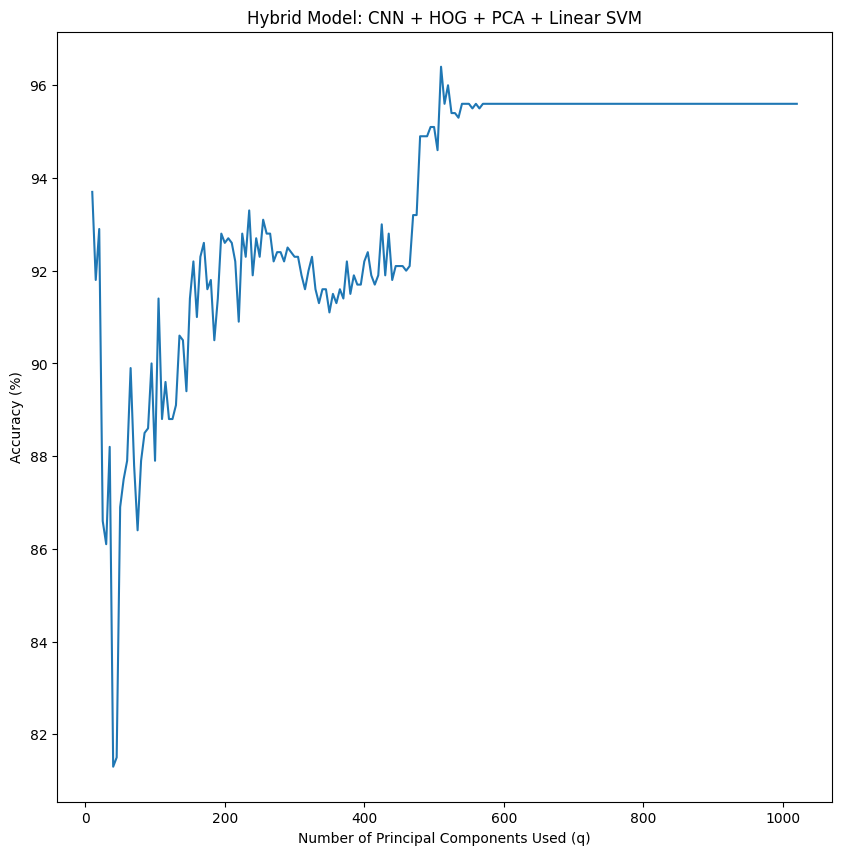

In [43]:
plt.figure(figsize=(10,10))
plt.title("Hybrid Model: CNN + HOG + PCA + Linear SVM")
plt.plot(np.arange(10,1025,5), np.array(svm_hybrid_accuracy_over_q)*100)
plt.xlabel("Number of Principal Components Used (q)")
plt.ylabel("Accuracy (%)")
plt.show()

In [44]:
for q in range(0, len(svm_hybrid_accuracy_over_q)+1, 10):
    print(f"Accuracy for Hybrid with PCA q={10+5*q} is: {svm_hybrid_accuracy_over_q[q]*100:.4f}%")

Accuracy for Hybrid with PCA q=10 is: 93.7000%
Accuracy for Hybrid with PCA q=60 is: 87.9000%
Accuracy for Hybrid with PCA q=110 is: 88.8000%
Accuracy for Hybrid with PCA q=160 is: 91.0000%
Accuracy for Hybrid with PCA q=210 is: 92.6000%
Accuracy for Hybrid with PCA q=260 is: 92.8000%
Accuracy for Hybrid with PCA q=310 is: 91.9000%
Accuracy for Hybrid with PCA q=360 is: 91.3000%
Accuracy for Hybrid with PCA q=410 is: 91.9000%
Accuracy for Hybrid with PCA q=460 is: 92.0000%
Accuracy for Hybrid with PCA q=510 is: 96.4000%
Accuracy for Hybrid with PCA q=560 is: 95.6000%
Accuracy for Hybrid with PCA q=610 is: 95.6000%
Accuracy for Hybrid with PCA q=660 is: 95.6000%
Accuracy for Hybrid with PCA q=710 is: 95.6000%
Accuracy for Hybrid with PCA q=760 is: 95.6000%
Accuracy for Hybrid with PCA q=810 is: 95.6000%
Accuracy for Hybrid with PCA q=860 is: 95.6000%
Accuracy for Hybrid with PCA q=910 is: 95.6000%
Accuracy for Hybrid with PCA q=960 is: 95.6000%
Accuracy for Hybrid with PCA q=1010 is: 95

Let us see what images the model missclassified:

Found 36 misclassified examples to visualize.
Plotting 3 images (every 10th misclassified example).


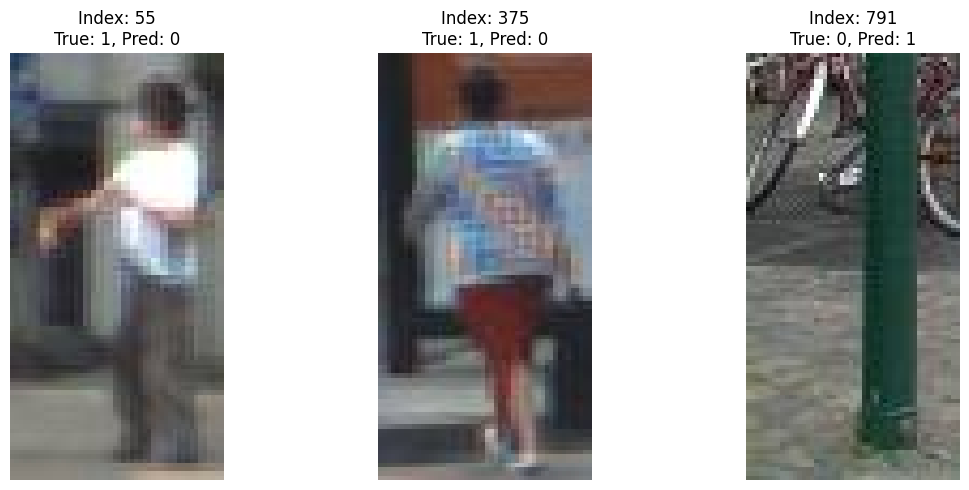

In [46]:
q = 510 # Based on the graph above
_ , _, predictions, error_indices = SVM_classifier(pca_trasformed_train_data[:,:q], train_classify, pca_trasformed_test_data[:,:q], test_classify)
print(f"Found {len(error_indices)} misclassified examples to visualize.")

indices_to_plot = error_indices[::15]
num_to_plot = len(indices_to_plot)

print(f"Plotting {num_to_plot} images (every 10th misclassified example).")

if num_to_plot > 0:

    fig, axes = plt.subplots(1, num_to_plot, figsize=(4 * num_to_plot, 5))
    if num_to_plot == 1:
        axes = [axes]
    for i, error_index in enumerate(indices_to_plot):
        image_to_plot = test_data[error_index]
        true_label = test_classify[error_index]
        predicted_label = predictions[error_index]

        title = f"Index: {error_index}\nTrue: {int(true_label)}, Pred: {int(predicted_label)}"
        plot_im(image_to_plot, ax=axes[i], title=title)

    plt.tight_layout()
    plt.show()

## Beyond PCA

As we saw, the model did not improve in performance drastically when using PCA (soemtimes not at all) - this hints that we need a better method of dimensionality reduction to reduce the features. We attempt to do this with the help of autoencoders.

In [9]:
# Load the .npz file
loaded_data = np.load('norm_combined_features.npz')

# These will be normalized!
combined_train_features = loaded_data['arr1']
combined_test_features = loaded_data['arr2']

print(f"Loaded train features shape: {combined_train_features.shape}")
print(f"Loaded test features shape: {combined_test_features.shape}")

Loaded train features shape: (2000, 22780)
Loaded test features shape: (1000, 22780)


In [12]:
# Autoencoder Architecture

inputs = keras.Input(shape=(combined_train_features.shape[1],))
# Input has shape 22780
dffnn_layer_1 = layers.Dense(units=4096, activation='relu')(inputs)
bn_layer = layers.BatchNormalization()(dffnn_layer_1)
dffnn_layer_2 = layers.Dense(units=512, activation='relu')(bn_layer)
bn_layer = layers.BatchNormalization()(dffnn_layer_2)
bottleneck = layers.Dense(units=128, activation='relu', name='bottleneck')(bn_layer)
# Encoder Model
encoder = Model(inputs=inputs, outputs=bottleneck, name='encoder')

# Decoder Input
latent_input = layers.Input(shape=(128,), name='decoder_input')
# bn_layer = layers.BatchNormalization()(latent_input) # Maybe can remove
reconstruct_layer_2 = layers.Dense(units=512, activation='relu')(latent_input)
bn_layer = layers.BatchNormalization()(reconstruct_layer_2)
reconstruct_layer_3 = layers.Dense(units=4096, activation='relu')(bn_layer)
bn_layer = layers.BatchNormalization()(reconstruct_layer_3)
dropout = layers.Dropout(rate=0.25)(bn_layer)
outputs = layers.Dense(units=combined_train_features.shape[1], activation='linear')(bn_layer)

# Decoder Model
decoder = Model(inputs=latent_input, outputs=outputs, name='decoder')

# The Full Autoencoder Model
autoencoder_model = Model(inputs=inputs, outputs=decoder(encoder(inputs)), name='autoencoder')

autoencoder_model.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 22780)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 128)            │    95,492,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 22780)          │    95,515,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,008,124 (728.64 MB)

 Trainable params: 190,989,692 (728.57 MB)

 Non-trainable params: 18,432 (72.00 KB)

In [13]:
# Cross Vaidation Set-up

num_folds = 5
ae_kfold = KFold(n_splits=5, shuffle=True)
batch_size = 64
epochs = 10

all_epoch_counts = []
fold_scores = []
best_score = -1

for fold, (train_indices, val_indices) in enumerate(ae_kfold.split(combined_train_features)):
    print(f"--- Starting Fold {fold+1}/{num_folds} ---")

    fold_train_data, fold_cv_data = combined_train_features[train_indices], combined_train_features[val_indices]

    # Create a fresh, untrained model for this fold
    model_for_fold = clone_model(autoencoder_model)

    # Learning Rate Set-Up
    decay_epochs = 30
    steps_per_epoch = combined_train_features.shape[0] / batch_size
    decay_steps = int(decay_epochs * steps_per_epoch)
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=1e-3, decay_steps=decay_steps, alpha=1e-2)
    optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-4)

    model_for_fold.compile(loss='mse', optimizer=optimizer)

    # To save the least overfit model
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
    print("\n Starting Training...")
    history = model_for_fold.fit(fold_train_data, fold_train_data,
                                 epochs=epochs, batch_size=batch_size,
                                 verbose=0, validation_data=(fold_cv_data, fold_cv_data),
                                 callbacks=[early_stopping])

    # See how many epochs were useful
    epochs_ran = len(history.history['loss'])
    print(f"Fold {fold+1} stopped after {epochs_ran} epochs.")

    all_epoch_counts.append(epochs_ran)

    # Evaluate on this fold's validation set
    final_mse = model_for_fold.evaluate(fold_cv_data, fold_cv_data, verbose=0)
    print(f"Score for fold {fold+1}: MSE = {final_mse:.4f}")
    fold_scores.append(final_mse)

print(f"\nAverage CV Loss (MSE): {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")

--- Starting Fold 1/5 ---

 Starting Training...
Restoring model weights from the end of the best epoch: 10.
Fold 1 stopped after 10 epochs.
Score for fold 1: MSE = 0.2015
--- Starting Fold 2/5 ---

 Starting Training...
Restoring model weights from the end of the best epoch: 10.
Fold 2 stopped after 10 epochs.
Score for fold 2: MSE = 0.1668
--- Starting Fold 3/5 ---

 Starting Training...
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
Fold 3 stopped after 5 epochs.
Score for fold 3: MSE = 0.5389
--- Starting Fold 4/5 ---

 Starting Training...
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 7.
Fold 4 stopped after 10 epochs.
Score for fold 4: MSE = 0.2747
--- Starting Fold 5/5 ---

 Starting Training...
Restoring model weights from the end of the best epoch: 8.
Fold 5 stopped after 10 epochs.
Score for fold 5: MSE = 0.2258

Average CV Loss (MSE): 0.2815 (+/- 0.1334)


In [14]:
# To be chosen:
optimal_epochs = 25 # Observed optimal epochs
batch_size = 64

print("\n--- Training Final Model on All Data ---")
final_autoencoder_model = clone_model(autoencoder_model)

# Learning Rate Set-Up
decay_epochs = 35
steps_per_epoch = combined_train_features.shape[0] / batch_size
decay_steps = int(decay_epochs * steps_per_epoch)
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=1e-3, decay_steps=decay_steps, alpha=1e-2)

optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-4)

final_autoencoder_model.compile(loss='mse', optimizer=optimizer)
final_autoencoder_model.fit(combined_train_features, combined_train_features, epochs=optimal_epochs, batch_size=batch_size, verbose=1)

final_autoencoder_model.save("final_autoencoder_model.keras")


--- Training Final Model on All Data ---
Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - loss: 0.6808
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.3685
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.3129
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2391
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.1984
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.1866
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.1594
Epoch 8/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.1313
Epoch 9/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1229
Epoch 10/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1010
Epoch 11/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0958
Epoch 12/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0780
Epoch 13/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0793
Epoch 14/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0774
Epoch 15/25
32/32 ━━━━━━━━━

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Shape of encoded train features: (2000, 128)
Accuracy of the CNN-HOG-AE-SVM model is: 89.60000000000001%
Found 104 misclassified examples to visualize.
Plotting 7 images (every 10th misclassified example).


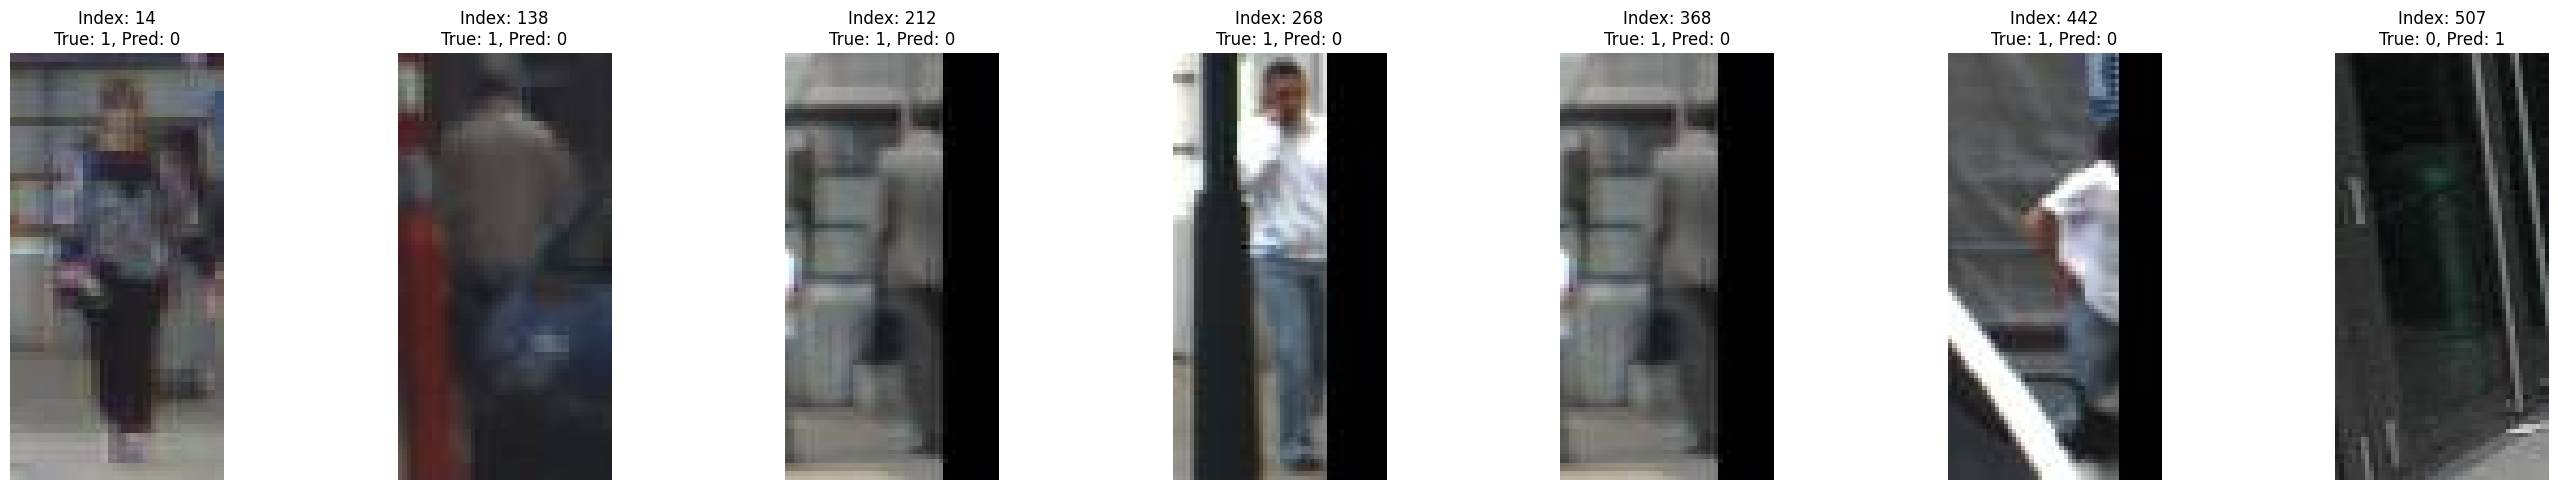

In [15]:
final_encoder = final_autoencoder_model.get_layer('encoder')

# 2. Now you can use this `final_encoder` directly for prediction.
encoded_train_features = final_encoder.predict(combined_train_features)
encoded_test_features = final_encoder.predict(combined_test_features)

print(f"Shape of encoded train features: {encoded_train_features.shape}")

_ , svm_accuracy, predictions, error_indices = SVM_classifier(encoded_train_features, train_classify, encoded_test_features, test_classify)
print(f"Accuracy of the CNN-HOG-AE-SVM model is: {svm_accuracy*100}%")
print(f"Found {len(error_indices)} misclassified examples to visualize.")

indices_to_plot = error_indices[::15]
num_to_plot = len(indices_to_plot)

print(f"Plotting {num_to_plot} images (every 10th misclassified example).")

if num_to_plot > 0:

    fig, axes = plt.subplots(1, num_to_plot, figsize=(4 * num_to_plot, 5))
    if num_to_plot == 1:
        axes = [axes]
    for i, error_index in enumerate(indices_to_plot):
        image_to_plot = test_data[error_index]
        true_label = test_classify[error_index]
        predicted_label = predictions[error_index]

        title = f"Index: {error_index}\nTrue: {int(true_label)}, Pred: {int(predicted_label)}"
        plot_im(image_to_plot, ax=axes[i], title=title)

    plt.tight_layout()
    plt.show()

Unfortunately, this method of dimensionality reduction did not yield the best results - one can try removing the the batch normalization here and may achieve better results, but we failed to achieve results that bettered our earlier CNN-HOG-SVM model. We leave this method as it introduces two new concepts - autoencoders and batch-normalization, which may be helpful with more data, in future use or different tasks.